## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

## Library functions

In [2]:
import torch
import math
from pytorch_msssim import SSIM
import torchvision
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [3]:
# Device to use for rendering, CUDA is highly recommended, CPU is not extensively tested, but will most likely be too slow to run.
device = torch.device("cuda:0")

In [4]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(a: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    m = torch.stack([
        torch.stack([torch.exp(a), torch.zeros_like(c)]),
        torch.stack([torch.zeros_like(a), torch.exp(c)])
    ]).permute(2, 0, 1)

    return m

In [5]:
# Render (channels x width x image) matrix for input parameters
def f_hat(
    color_zeroth: torch.Tensor,
    color_first: torch.Tensor,
    color_second: torch.Tensor,
    scale_shear: torch.Tensor,
    rotation: torch.Tensor,
    translation: torch.Tensor,
    width: int,
    height: int
) -> torch.Tensor:
    """
    Calculate f_hat with w for the grid width to height
    """

    Y = exp_SNM(scale_shear[:, 0], scale_shear[:, 1])

    A = exp_SO(rotation) @ Y

    sampling_grid = torch.nn.functional.affine_grid(
        torch.cat([torch.linalg.inv(A), (torch.linalg.inv(A) @ (translation*-1).unsqueeze(-1))], dim=-1), 
        torch.Size((A.size()[0], 1, height, width)), align_corners=False)
    zeroth_gaussian_values = torch.exp(-1 * (sampling_grid[:,:,:,1]**2 + sampling_grid[:,:,:,0]**2))
    zeroth_image = torch.einsum('gjk,gd->gdjk', zeroth_gaussian_values, color_zeroth).sum(dim=0)

    first_gaussian_values =  -2 * (sampling_grid[:, :,:, 0]/0.7) * torch.exp(-1 * ((sampling_grid[:,:,:,0]/0.7)**2 + sampling_grid[:,:,:,1]**2))
    first_image = torch.einsum('gjk,gd->gdjk', first_gaussian_values, color_first).sum(dim=0)

    second_gaussian_values = (4 * (sampling_grid[:, :,:, 0]/0.5)**2 - 2) * torch.exp(-1 * ((sampling_grid[:,:,:,0]/0.5)**2 + sampling_grid[:,:,:,1]**2))
    second_image = torch.einsum('gjk,gd->gdjk', second_gaussian_values, color_second).sum(dim=0)

    # print(zeroth_gaussian_values.shape, color_zeroth.abs().shape)
    # return LinearSigmoid.apply(zeroth_image + first_image + second_image)
    return zeroth_image + first_image + second_image + 0.5


In [6]:

def train(learning_rate: float, iterations: int, guassians: int, target: torch.Tensor,
          culling=True,
          sizing_loss=True):

    ssim_module = SSIM(data_range=1, size_average=True, channel=3)
    lambda_ = 0.9

    color_zeroth = torch.randn(guassians, 3, device=device).abs().requires_grad_(True)
    color_first = (torch.randn(guassians, 3, device=device)*0.1).requires_grad_(True)
    color_second = (torch.randn(guassians, 3, device=device)*0.1).requires_grad_(True)

    scale_shear = (torch.randn(guassians, 2, device=device) - 4).requires_grad_(True)
    rotation = ((torch.rand(guassians, device=device) - 0.5) * math.pi * 2).requires_grad_(True)
    translation = torch.randn(guassians, 2, device=device, requires_grad=True)

    optimizer = torch.optim.AdamW(
        [
            color_zeroth,
            (color_first), 
            (color_second), 
            scale_shear,
            rotation,
            translation,
        ],
        lr=learning_rate,
        betas=(0.5, 0.9),
    )
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=iterations)

    mask = torch.ones(guassians, dtype=torch.bool, device=device)

    for iteration in range(iterations):

        preds = f_hat(
            color_zeroth[mask], 
            (color_first[mask]), 
            (color_second[mask]), 
            scale_shear[mask],
            rotation[mask],
            translation[mask],
            target.size()[1], target.size()[2])

        ssim_loss = 1 - ssim_module(preds.unsqueeze(0), target.unsqueeze(0))
        l1_loss = (target - preds).abs().mean()
        
        loss = (1 - lambda_) * ssim_loss + lambda_ * l1_loss + (scale_shear[:, 0] - scale_shear[:, 1]).abs().mean() * 0.1
        if sizing_loss:
            loss = loss + torch.exp(-scale_shear.sum(1)-8).mean() * 0.1


        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        if iterations > 10 and (iteration + 1) % round(iterations/10) == 0:
            print(f"Iteration {iteration+1}/{iterations}. Loss: {loss.item():0.5f}")

        if round(iterations/10)*7 == iteration and culling:
            mask = scale_shear.sum(1) > -7.5
            print(f"Culling {mask.sum()}")
            
    preds = f_hat(
            color_zeroth[mask], 
            color_first[mask], 
            color_second[mask], 
            scale_shear[mask],
            rotation[mask],
            translation[mask],
            target.size()[1], target.size()[2])
    
    ssim_loss = 1 - ssim_module(preds.unsqueeze(0), target.unsqueeze(0))
    l1_loss = (target - preds).abs().mean()
    
    loss = (1 - lambda_) * ssim_loss + lambda_ * l1_loss + (scale_shear[:, 0] - scale_shear[:, 1]).abs().mean() * 0.1 
    
    if sizing_loss:
        loss = loss + torch.exp(-scale_shear.sum(1)-8).mean() * 0.1

    if culling:
        shear_mask = scale_shear.sum(1) > -7.5
        color_mask = (color_zeroth.abs().sum(1) > 0.05) | (color_first.abs().sum(1) > 0.05) | (color_second.abs().sum(1) > 0.05)
        mask = mask & shear_mask & color_mask.to(device)

    # Clear iteration prints
    clear_output()
    print("Training summary:")
    print(f"Iterations: {iterations}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Guassians used: {mask.sum().item()}/{guassians}")
    print(f"SSIM Loss: {ssim_loss.item():.4f}")
    print(f"L1 Loss: {l1_loss.item():.4f}")
    print(f"Final loss: {loss.item():.4f}")

    return loss, color_zeroth[mask], color_first[mask], color_second[mask], scale_shear[mask], rotation[mask], translation[mask]

In [7]:
def img_to_tensor(img_path: str) -> torch.Tensor:
    return torchvision.io.read_image(img_path)

In [8]:
def plot_original(img_tensor: torch.Tensor):
    plt.title(f"Original image | {img_tensor.size()[1]}x{img_tensor.size()[2]}")
    plt.imshow(img_tensor.permute(1, 2, 0), origin='upper')
    plt.axis('off')
    clear_output()
    plt.show()

In [9]:
def plot_image(color_zeroth: torch.Tensor,
    color_first: torch.Tensor,
    color_second: torch.Tensor,
    scale_shear: torch.Tensor,
    rotation: torch.Tensor,
    translation: torch.Tensor, resolution, loss):
    color_zeroth = color_zeroth.detach().cpu()
    color_first = color_first.detach().cpu()
    color_second = color_second.detach().cpu()
    scale_shear = scale_shear.detach().cpu()
    rotation = rotation.detach().cpu()
    translation = translation.detach().cpu()
    plt.title(f"Reconstruction | {resolution}x{resolution}\nGaussians: {scale_shear.size()[0]} | Loss: {loss.item():.4f}")
    plt.imshow(f_hat(color_zeroth, color_first, color_second, scale_shear, rotation, translation, resolution, resolution).permute(1, 2, 0), origin='upper', vmin=0, vmax=1)
    plt.axis('off')
    clear_output()
    plt.show()

In [10]:
def plot_accents(color_first: torch.Tensor,
    color_second: torch.Tensor,
    scale_shear: torch.Tensor,
    rotation: torch.Tensor,
    translation: torch.Tensor, resolution, loss):
    color_first = color_first.detach().cpu()
    color_second = color_second.detach().cpu()
    scale_shear = scale_shear.detach().cpu()
    rotation = rotation.detach().cpu()
    translation = translation.detach().cpu()

    f_hat_result = f_hat(torch.zeros_like(color_first), color_first, color_second, scale_shear, rotation, translation, resolution, resolution).permute(1, 2, 0)

    plt.title(f"Accents of representation | {resolution}x{resolution}\nGaussians: {scale_shear.size()[0]} | Loss: {loss.item():.4f}")
    plt.imshow(
        torch.gather(f_hat_result, -1, f_hat_result.abs().max(-1, keepdim=True)[1]).squeeze(), origin='upper', cmap="plasma", vmin=-1, vmax=1)

Execute all the functions above to run code blocks below

------------------------

## Visualization of individual gaussians

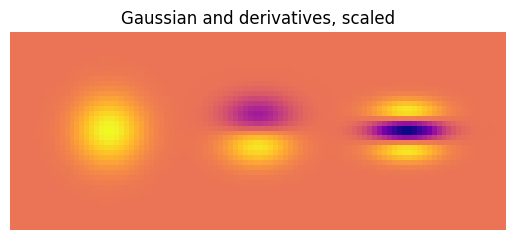

In [41]:
# w = torch.tensor([[-1,  -2, 1,  torch.pi/1.5, 0.5 - 2, 0.2 + 1], [-1,  -2, 1,  torch.pi/1.5, 0.5 - 2, 0.2 + 1]]).permute(1, 0)
w_prime = torch.tensor([[0, 0, 1,  -3, -3, -0.8,  0.45, 0.42], [1, 0, 0,  -2.5, -2.5, -0.8,  0.45, 0.42]]).permute(1, 0)

color_zeroth = torch.tensor([[0.5, 0.5, 0.5], [0, 0, 0], [0, 0, 0]])
color_first = torch.tensor([[0, 0, 0], [0.5, 0.5, 0.5], [0, 0, 0]])
color_second = torch.tensor([[0, 0, 0], [0, 0, 0], [0.5, 0.5, 0.5]])
scale_shear = torch.tensor([[ -2, -2], [ -2, -2], [ -2, -2]])
rotation = torch.tensor([math.pi/2, math.pi/2, math.pi/2])
translation = torch.tensor([[-0.6, 0], [0, 0], [0.6, 0]])

plt.title("Gaussian and derivatives, scaled")
img = f_hat(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, 100).permute(1, 2, 0)[30:70, :].mean(-1)
plt.imshow(img, origin='lower', cmap='plasma')
plt.axis('off')
plt.show()

---

Each expirement is divided by horizontal lines, it starts with the original picture, then a training block, then visualizations of the results.

---
## Castle: 

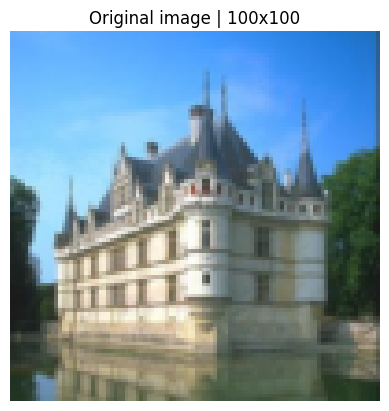

In [15]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd300-castle.jpg'), 0, 0, 321, 321).float()

output_z = torchvision.transforms.Resize(100)(img) / 255.0
plot_original(output_z);

In [16]:
learning_rate = 0.01
iterations = 750
guassians = 1500


loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device))

Training summary:
Iterations: 750
Learning Rate: 0.01
Guassians used: 1440/1500
SSIM Loss: 0.0363
L1 Loss: 0.0117
Final loss: 0.0308


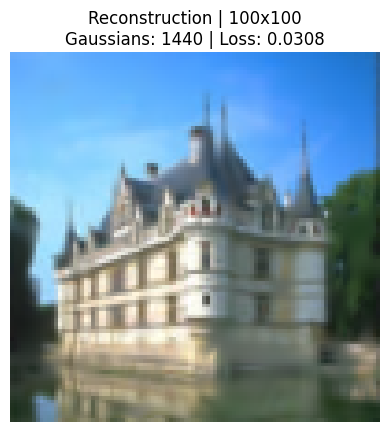

In [17]:
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, loss)

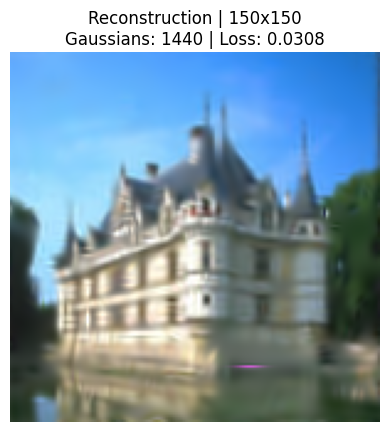

In [ ]:
# Upscaled
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 150, loss)

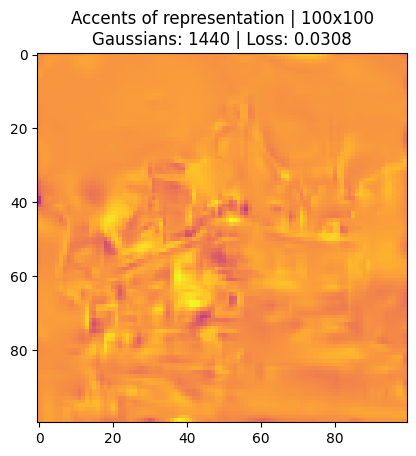

In [19]:
plot_accents(color_first, color_second, scale_shear, rotation, translation, 100, loss)

---
## Castle: Low amount of gaussian 

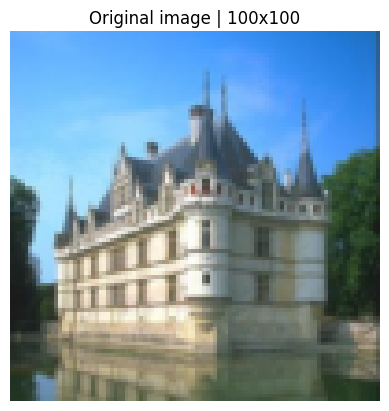

In [108]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd300-castle.jpg'), 0, 0, 321, 321).float()

output_z = torchvision.transforms.Resize(100)(img) / 255.0
plot_original(output_z);

In [112]:
learning_rate = 0.01
iterations = 750
guassians = 750


loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device))

Training summary:
Iterations: 750
Learning Rate: 0.01
Guassians used: 733/750
SSIM Loss: 0.0770
L1 Loss: 0.0186
Final loss: 0.0390


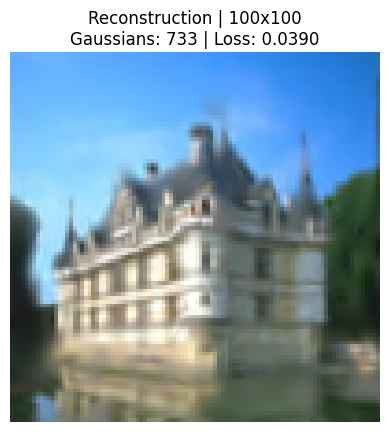

In [113]:
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, loss)

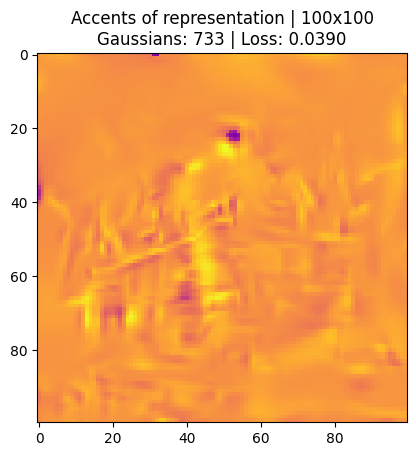

In [116]:
plot_accents(color_first, color_second, scale_shear, rotation, translation, 100, loss)

---
## Castle: High amount of gaussians

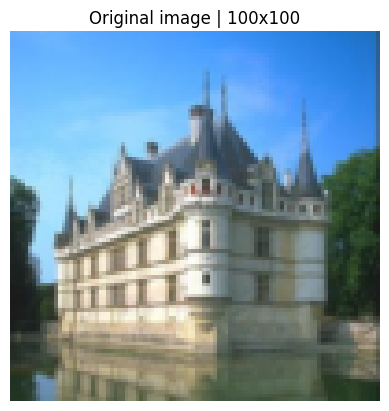

In [10]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd300-castle.jpg'), 0, 0, 321, 321).float()

output_z = torchvision.transforms.Resize(100)(img) / 255.0
plot_original(output_z);

In [12]:
learning_rate = 0.01
iterations = 1000
guassians = 3000


loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device))

Training summary:
Iterations: 1000
Learning Rate: 0.01
Guassians used: 2816/3000
SSIM Loss: 0.0088
L1 Loss: 0.0056
Final loss: 0.0196


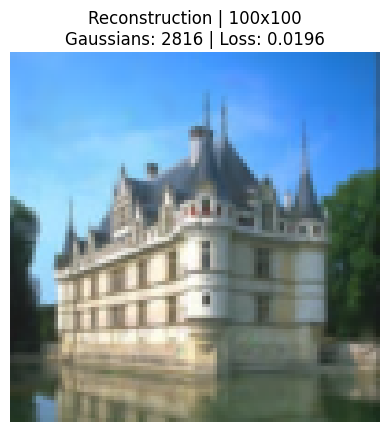

In [13]:
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, loss)

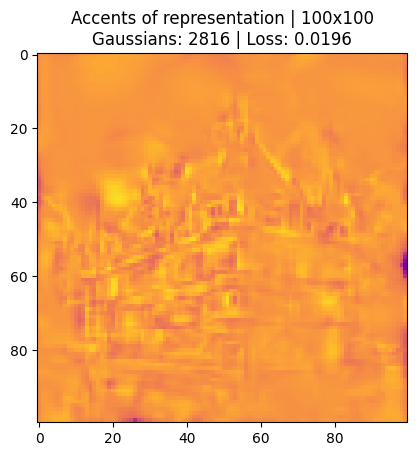

In [14]:
plot_accents(color_first, color_second, scale_shear, rotation, translation, 100, loss)

---
## Castle: No size in loss, with culling

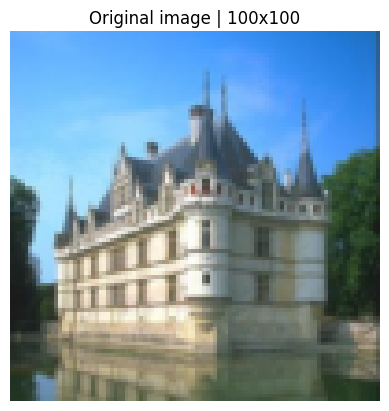

In [20]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd300-castle.jpg'), 0, 0, 321, 321).float()

output_z = torchvision.transforms.Resize(100)(img) / 255.0
plot_original(output_z);

In [21]:
learning_rate = 0.01
iterations = 750
guassians = 1500


loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device), sizing_loss=False)

Training summary:
Iterations: 750
Learning Rate: 0.01
Guassians used: 600/1500
SSIM Loss: 0.0942
L1 Loss: 0.0209
Final loss: 0.0324


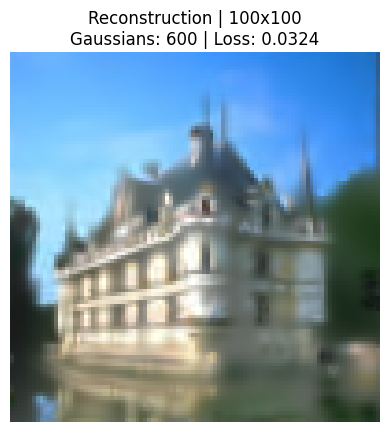

In [22]:
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, loss)

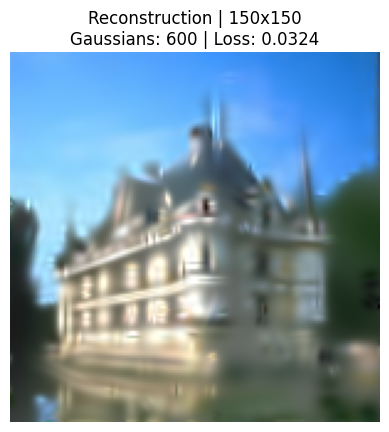

In [23]:
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 150, loss)

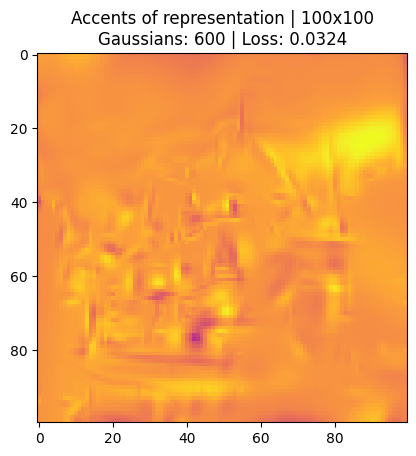

In [24]:
plot_accents(color_first, color_second, scale_shear, rotation, translation, 100, loss)

---
## Castle: No culling, no size in loss

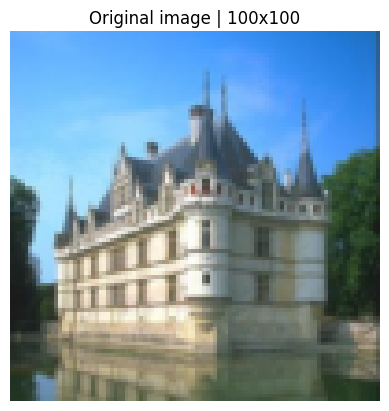

In [32]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd300-castle.jpg'), 0, 0, 321, 321).float()

output_z = torchvision.transforms.Resize(100)(img) / 255.0
plot_original(output_z);

In [33]:
learning_rate = 0.01
iterations = 750
guassians = 1500


loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device), sizing_loss=False, culling=False)

Training summary:
Iterations: 750
Learning Rate: 0.01
Guassians used: 1500/1500
SSIM Loss: 0.0697
L1 Loss: 0.0174
Final loss: 0.0256


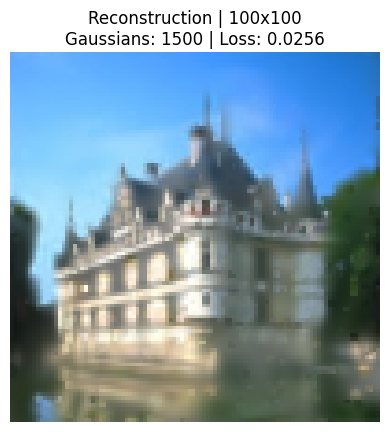

In [34]:
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, loss)

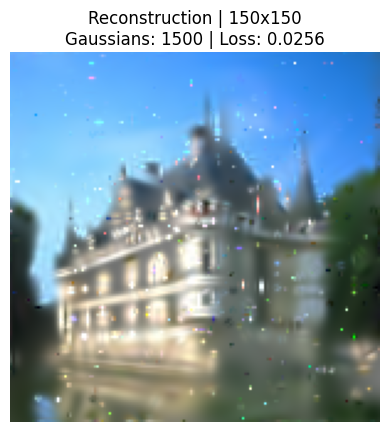

In [35]:
# Upscaled
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 150, loss)

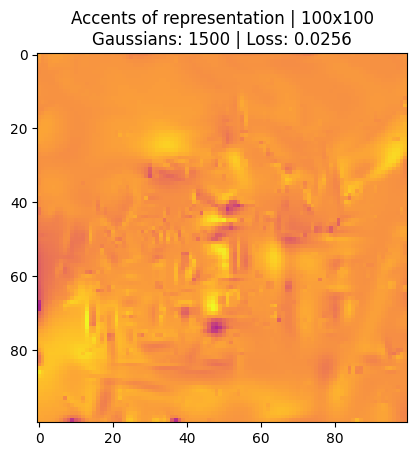

In [36]:
plot_accents(color_first, color_second, scale_shear, rotation, translation, 100, loss)

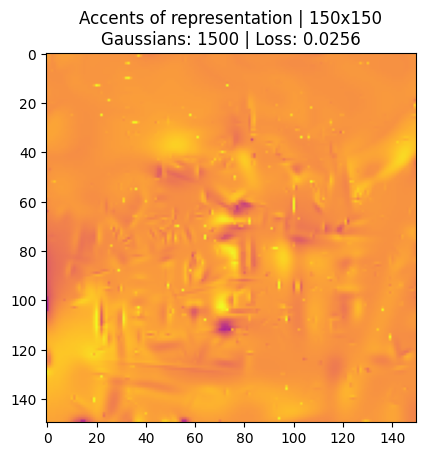

In [37]:
# Upscaled
plot_accents(color_first, color_second, scale_shear, rotation, translation, 150, loss)

---
Cars: 

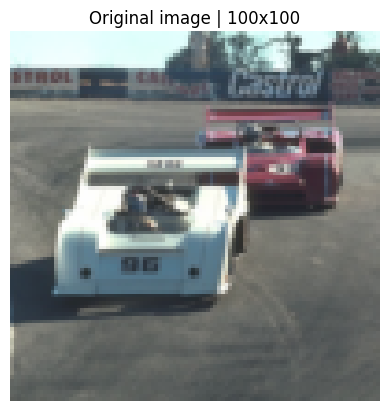

In [25]:

img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd68-0005.png'), 0, 440-321, 321, 321).float()

output_z = torchvision.transforms.Resize(100)(img) / 255.0
plot_original(output_z)


In [26]:
learning_rate = 0.01
iterations = 750
guassians = 1500

loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device))

Training summary:
Iterations: 750
Learning Rate: 0.01
Guassians used: 1444/1500
SSIM Loss: 0.0358
L1 Loss: 0.0119
Final loss: 0.0322


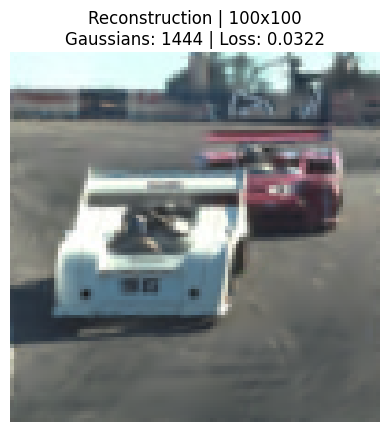

In [27]:
plot_image((color_zeroth), (color_first), (color_second), scale_shear, rotation, translation, 100, loss)

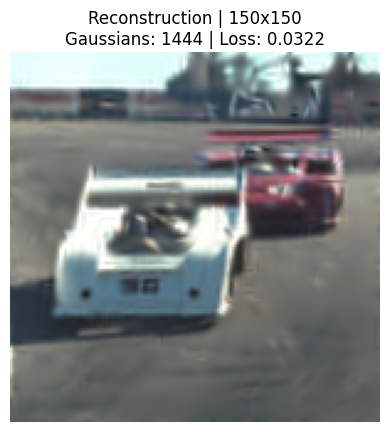

In [ ]:
# Upscaled
plot_image((color_zeroth), (color_first), (color_second), scale_shear, rotation, translation, 150, loss)

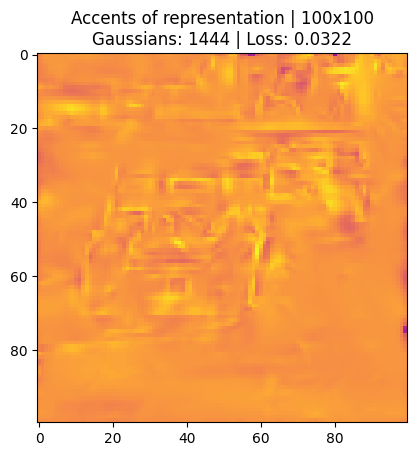

In [28]:
plot_accents((color_first), (color_second), scale_shear, rotation, translation, 100, loss)

---
## Cars: High gaussians 

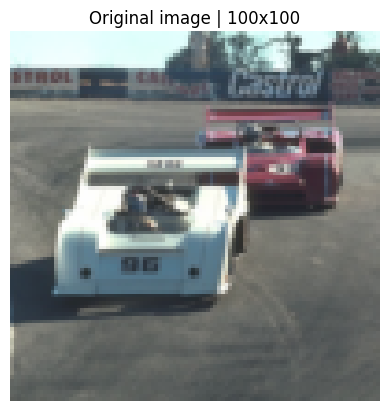

In [10]:

img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd68-0005.png'), 0, 440-321, 321, 321).float()

output_z = torchvision.transforms.Resize(100)(img) / 255.0
plot_original(output_z)


In [12]:
learning_rate = 0.01
iterations = 1000
guassians = 3000

loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device))

Training summary:
Iterations: 1000
Learning Rate: 0.01
Guassians used: 2892/3000
SSIM Loss: 0.0124
L1 Loss: 0.0063
Final loss: 0.0208


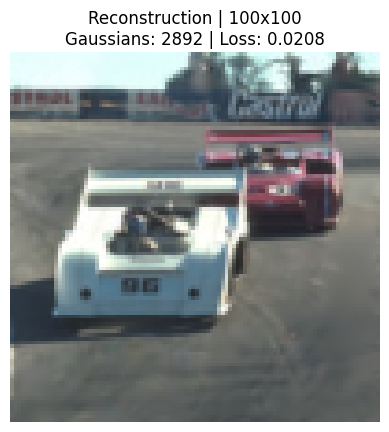

In [13]:
plot_image((color_zeroth), (color_first), (color_second), scale_shear, rotation, translation, 100, loss)

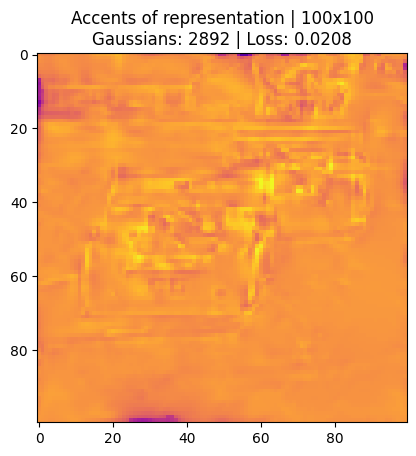

In [14]:
plot_accents((color_first), (color_second), scale_shear, rotation, translation, 100, loss)

---
## Veins: Low amount of gaussians

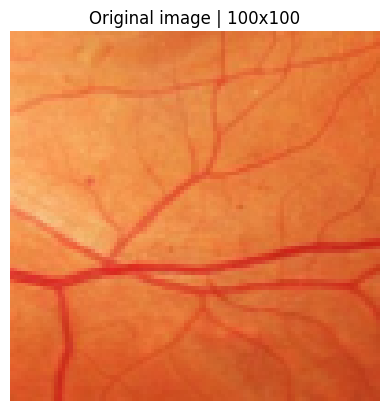

In [21]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()
output_z = torchvision.transforms.Resize(100)(img) / 255

plot_original(output_z);

In [23]:
learning_rate = 0.01
iterations = 1000
guassians = 750

loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device))

Training summary:
Iterations: 1000
Learning Rate: 0.01
Guassians used: 745/750
SSIM Loss: 0.0721
L1 Loss: 0.0089
Final loss: 0.0243


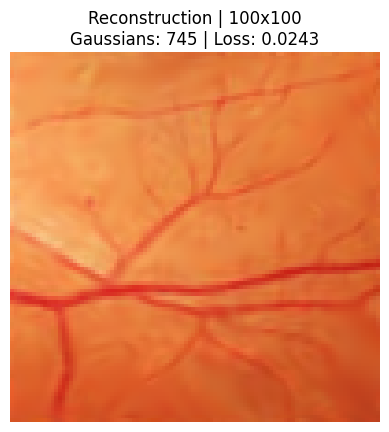

In [24]:
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, loss)

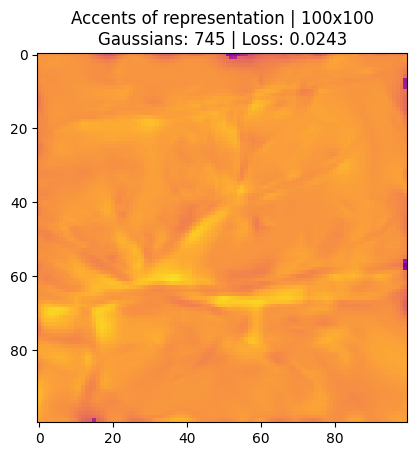

In [25]:
plot_accents(color_first, color_second, scale_shear, rotation, translation, 100, loss)

---
## Veins: High amount of gauassians

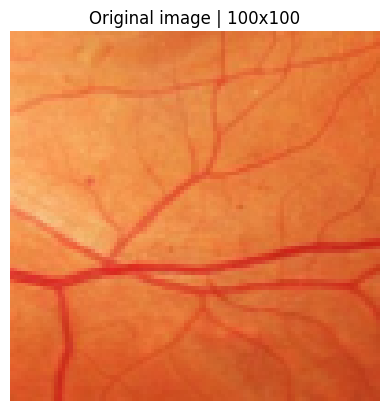

In [26]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()
output_z = torchvision.transforms.Resize(100)(img) / 255

plot_original(output_z);

In [27]:
learning_rate = 0.01
iterations = 1000
guassians = 3000

loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z.to(device))

Training summary:
Iterations: 1000
Learning Rate: 0.01
Guassians used: 2833/3000
SSIM Loss: 0.0150
L1 Loss: 0.0041
Final loss: 0.0188


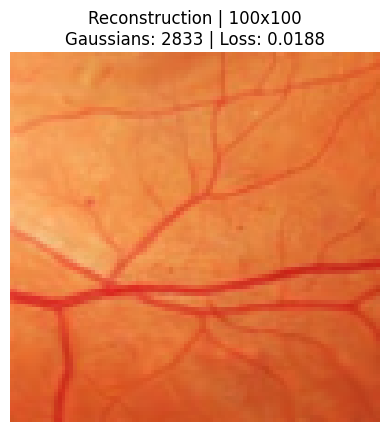

In [28]:
plot_image(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, loss)

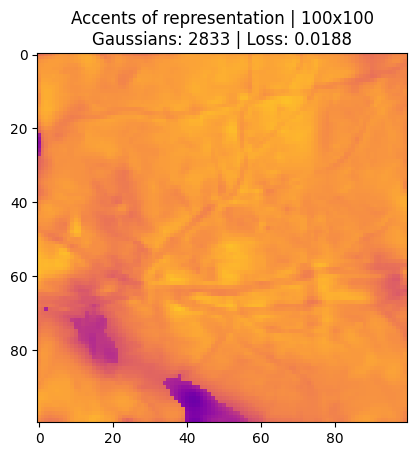

In [29]:
plot_accents(color_first, color_second, scale_shear, rotation, translation, 100, loss)